In [373]:
cd  AraABSAMD

[WinError 2] The system cannot find the file specified: 'AraABSAMD'
C:\Users\youssef\prompt engeneering\Education data\AllDAta\AraABSAMD


In [374]:
import re
def clean(text):
    # Replace HTML line breaks with a space
    text = text.replace("<br/>", " ")
    
    # Remove tab characters (delete them entirely)
    text = text.replace("\t", "")
    
    # Keep only Arabic letters (Unicode range 0621-064A) and spaces.
    # Any other character is replaced with a space.
    strip_special_chars = re.compile(u'[^\u0621-\u064a ]')
    return re.sub(strip_special_chars, " ", text)

In [376]:
import xml.etree.ElementTree as ET
import os



# List to hold all (text, polarity) tuples
all_data = []

# Get all XML files in the current directory
# You can change the path by providing a directory, e.g., os.listdir('/path/to/xml/files')
xml_files = [f for f in os.listdir('.') if f.endswith('.xml')]

for xml_file in xml_files:
    print(f"Processing {xml_file}...")
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        for sentence in root:
            # Extract sentence text
            text_elem = sentence.find('text')
            if text_elem is None or text_elem.text is None:
                continue
            text = clean(text_elem.text)

            # Find aspectCategories container
            aspect_categories = sentence.find('aspectCategories')
            if aspect_categories is None:
                continue

            # Get the first aspectCategory (if any)
            first_aspect = aspect_categories.find('aspectCategory')
            if first_aspect is not None:
                polarity = first_aspect.attrib.get('polarity')
                if polarity:   # only add if polarity exists
                    all_data.append((text, polarity.lower()))
    except Exception as e:
        print(f"Error processing {xml_file}: {e}")

# Now all_data contains tuples from all XML files
print(f"Total extracted pairs: {len(all_data)}")
# You can now use all_data as needed, e.g., convert to DataFrame, etc.

Processing AraABSAMD1.xml...
Processing AraABSAMD2.xml...
Processing AraABSAMD3.xml...
Processing AraABSAMD4.xml...
Processing AraABSAMD5.xml...
Processing AraABSAMD6.xml...
Processing AraABSAMD7.xml...
Total extracted pairs: 1360


In [377]:
print(all_data)

[('لما كانت المدرسة و التعليم في المغرب  له شان    ', 'positive'), (' مع بداية العام الدراسي  الآباء محتارون بين التعليم العمومي والخاص   أيهما الأفضل لأطفالهم في ظل الغلاء    الدخول المدرسي  تعليم  دراسة  المغرب', 'positive'), ('البعثات الداخلية والانسحاب   بقلم  هدى حمد  جريدة ع مان  عدد الأثنين   سبتمبر     م   أسوأ ما قد ي جابهه شاب صغير السن  م قبل على أول سلمة في حياته التعليمية بعد الدبلوم العام  أن يضطر إلى التخلي عن فرصته  التي سترسم معالم مستقبله وستغير حياته  لا لشيء سوى أن  أسرته لا تستطيع أن', 'neutral'), ('الأرقام صادمة  وتلاميذ ما زالوا يتعثرون في أبسط التعلمات  هكذا وصف شكيب بنموسى  وزير التربية الوطنية والتعليم الأولي والرياضة  وضعية منظومة التعليم العمومي  مشددا على أنه لا بد من تنزيل الإصلاح   فالوضعية ليست فقط مقلقة  وإنما يمكن اعتبارها كارثية   وأوضح الوزير الوصي على قطاع', 'negative'), ('يقول الخبراء ان التعليم المدرسي سيشهد في المستقبل القريب تحولات كبيرة في طبيعته بسبب التطور التكنولوجي والتغيرات الاجتماعية والاقتصادية حيث سيكون التعليم أكثر تخصيص ا بحيث تصمم ال

In [378]:
# import pandas to use pandas DataFrame
import pandas as pd
# create an Empty DataFrame
# object With column names only
ll=[]
data = pd.DataFrame(columns=['Sentence', 'Polarity'])



  #d = pd.DataFrame(l, columns =['word', 'tag'])
#data.append(ll)
data = pd.DataFrame(all_data, columns =['Sentence', 'Polarity'])

In [379]:
data.head()

,Sentence,Polarity
0,لما كانت المدرسة و التعليم في المغرب له شان,positive
1,مع بداية العام الدراسي الآباء محتارون بين ال...,positive
2,البعثات الداخلية والانسحاب بقلم هدى حمد جر...,neutral
3,الأرقام صادمة وتلاميذ ما زالوا يتعثرون في أبس...,negative
4,يقول الخبراء ان التعليم المدرسي سيشهد في المست...,positive


In [285]:
data['Polarity']

0       positive
1       negative
2        neutral
3        neutral
4       positive
          ...   
1355    positive
1356    positive
1357     neutral
1358    positive
1359    negative
Name: Polarity, Length: 1360, dtype: object

In [286]:
import os
import openai
import tiktoken
import time

In [287]:
import openai
from datasets import load_dataset
import json
import pandas as pd
import tiktoken
import seaborn as sns
import matplotlib.pyplot as plt

In [288]:
openai.api_key="Your Api key"

In [289]:
data['Polarity'].value_counts()


Polarity
positive    593
negative    514
neutral     154
conflict     99
Name: count, dtype: int64

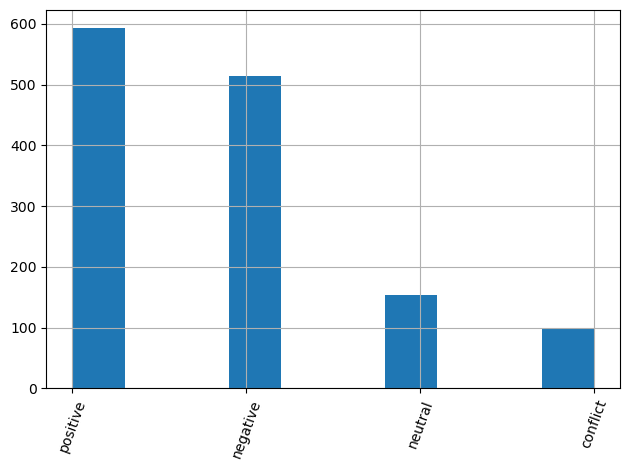

In [291]:
data['Polarity'].hist()
plt.xticks(rotation=70)
plt.tight_layout()

C:\Users\youssef\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


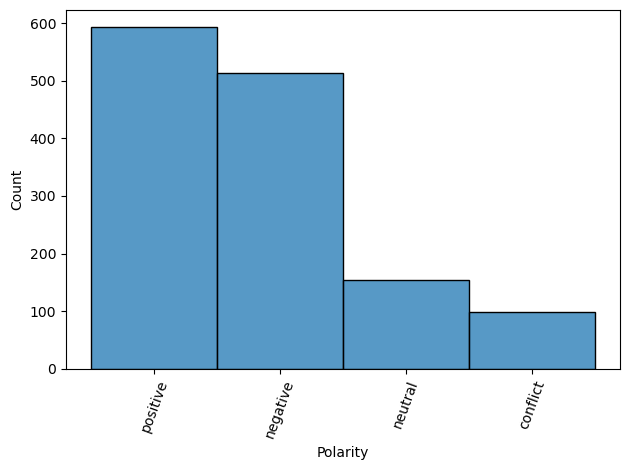

In [292]:


sns.histplot(data=data, x= 'Polarity')
plt.xticks(rotation=70)
plt.tight_layout()

In [298]:
len(data)

1360

In [299]:
from sklearn.model_selection import train_test_split
examples_df, gold_examples_df = train_test_split(
    data, 
    test_size=0.2,
    random_state=42
)

In [300]:
(examples_df.shape, gold_examples_df.shape)

((1088, 2), (272, 2))

In [301]:
examples_df['Polarity'].value_counts()

Polarity
positive    473
negative    402
neutral     133
conflict     80
Name: count, dtype: int64

In [302]:
examples_df = examples_df.reset_index()

In [304]:
columns_to_select = ['Sentence', 'Polarity']
gold_examples = gold_examples_df.loc[:, columns_to_select]
#gold_examples = gold_examples.sample(20, random_state=42) .to_json(orient='records', force_ascii=False)


positive_reviews = (gold_examples_df.Polarity == 'positive')
negative_reviews = (gold_examples_df.Polarity == 'negative')
neutral_reviews = (gold_examples_df.Polarity == 'neutral')
conflict_reviews = (gold_examples_df.Polarity == 'conflict')
columns_to_select = ['Sentence', 'Polarity']
positive_examples = gold_examples.loc[positive_reviews, columns_to_select].sample(4)
negative_examples = gold_examples.loc[negative_reviews, columns_to_select].sample(4)
neutral_examples = gold_examples.loc[neutral_reviews, columns_to_select].sample(4)
conflict_examples = gold_examples.loc[conflict_reviews, columns_to_select].sample(4)
examples = pd.concat([positive_examples,negative_examples,neutral_examples,conflict_examples])
#randomized_examples = examples.sample(4*5, replace=True)
gold_examples = examples.sample(16, random_state=42) .to_json(orient='records', force_ascii=False)



In [305]:
examples

,Sentence,Polarity
261,كأكاديمية أرى يومي ا أثر فجوة مخرجات التعليم ...,positive
237,لمن سألني عن ملزمة الكتابة هذه ملزمة رائعة للق...,positive
49,يحدث الآن ينظم المركز الوطني للتعليم الإل...,positive
1306,منذ التحاقك بالصف الأول الابتدائي حتى تتخرج من...,positive
259,عبد الإله بنكيران ازدواجية الخطاب وخيانة الثق...,negative
730,أي واحد يطل على مطابيع اللغة العربية في المغرب...,negative
597,عقب انتشار مقطع فيديو على الصفحات المغربية بمو...,negative
538,يسجلون أولادهم في المدارس الخاصة ثم يشتكون من ...,negative
405,كتاب يتناول العلاقة بين العلماء والدولة في الم...,neutral
1065,ساهمت التساقطات المطرية الأخيرة التي شهدها ال...,neutral


In [306]:
len(conflict_examples)

4

In [307]:
len(gold_examples)

4674

In [308]:
gold_examples

'[{"Sentence":"كأكاديمية  أرى يومي ا أثر فجوة مخرجات التعليم العام على طلاب التعليم العالي  نتائج التحصيلي لا تعكس ضعف المعلم  بل ضعف التوازن في المنظومة كاملة  المعلم هو الركيزة الأساسية  لكن التعليم لا يقوم عليه وحده  فليس المعلم       عصا العجوز       التي يتكئ عليها النظام بأكمله  التعليم منظومة تقوم","Polarity":"positive"},{"Sentence":"لمن سألني عن ملزمة الكتابة هذه ملزمة رائعة للقراءة والكتابة أراها الأفضل في تعليم القراءة والكتابة للأطفال مع التحية والتقدير  للأستاذ عبدالرحمن الطريس                 والأستاذ لافي اللافي  على جهدهما القيم في إعدادها وإخراجها على هذا الوجه الرائع                                                                          ","Polarity":"positive"},{"Sentence":"أي واحد يطل على مطابيع اللغة العربية في المغرب غيفهم راها تربية إسلامية ماشي لغة عربية تبارك الله على دواعش التعليم عندنا","Polarity":"negative"},{"Sentence":"ربما أنتم مثل الجزائر بكالوريس فالدكتوراه مباشرة  وهذه طريقة تنظيمية لإعداد محدد  لا يلتقط الطالب أنفاسه ولا يتكون بشكل جي د  ربما يفسر هذا

In [309]:
def create_examples(dataset, n=4):
    positive_reviews = (dataset.Polarity == 'positive')
    negative_reviews = (dataset.Polarity == 'negative')
    neutral_reviews = (dataset.Polarity == 'neutral')
    conflict_reviews = (dataset.Polarity == 'conflict')
    columns_to_select = ['Sentence', 'Polarity']
    positive_examples = dataset.loc[positive_reviews, columns_to_select].sample(n)
    negative_examples = dataset.loc[negative_reviews, columns_to_select].sample(n)
    neutral_examples = dataset.loc[neutral_reviews, columns_to_select].sample(n)
    conflict_examples = dataset.loc[conflict_reviews, columns_to_select].sample(n)
    examples = pd.concat([positive_examples,negative_examples,neutral_examples,conflict_examples])
    randomized_examples = examples.sample(4*n, replace=True)
    return randomized_examples.to_json(orient='records')

In [310]:
examples = create_examples(examples_df, n=4)

In [311]:
json.loads(examples)

[{'Sentence': ' عناصر تقييم الأداء الوظيفي  شرح وتطبيق    عنصر التقييم        أداء الواجبات الوظيفية       الوزن النسبي                   ي عد عنصر  أداء الواجبات الوظيفية  من أهم معايير تقييم المعلم  حيث يعكس مدى التزامه بالأنظمة والقوانين  وأخلاقيات المهنة  ومسؤوليته تجاه البيئة التعليمية  يتطلب هذا العنصر',
  'Polarity': 'positive'},
 {'Sentence': 'في سابقة عربية هي الأولى أعلن  المغرب إدراج التاريخ والثقافة اليهودية في مناهج التدريس عبر إجراء إصلاح تربوي شامل يأخذ بعين الاعتبار خصوصيات الجالية اليهودية في المغرب  ',
  'Polarity': 'neutral'},
 {'Sentence': 'التعليم الخصوصي جحيم للأسر وبزنس لمول الشكارة   التعليم الخصوصي فالمغرب كيقرى فيه أكثر من مليون و    ألف تلميذ  يعني واحد على كل سبعة تلاميذ كيقرا بالفلوس   عدد المؤسسات الخاصة في القطاع  وصلت  لأكثر من       مدرسة في كل المغرب  بزاف  ولكن السؤال  واش هاد الكثرة معناها الجودة',
  'Polarity': 'negative'},
 {'Sentence': 'بعض الناس يبدا بتعلم لغة اخرى مثل الانجليزية  ولكنه يواجه بعض الصعوبات في البداية  فيحكم على نفسه بالفشل سريعا  

In [312]:
user_message_template = """```{Education_review}```"""

In [313]:
zero_shot_system_message = """
Classify into only the following sentiment the reviews presented in the input :positive, negative, neutral, conflict.
Education reviews will be delimited by triple backticks in the input.
 Answer only positive, negative, neutral, conflict. Do not explain your answer.
"""

In [314]:
zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]

In [316]:
positive_reviews = (examples_df.Polarity == 'positive')
negative_reviews = (examples_df.Polarity == 'negative')
neutral_reviews = (examples_df.Polarity == 'neutral')
conflict_reviews = (examples_df.Polarity == 'conflict')

In [317]:
(positive_reviews.shape, negative_reviews.shape, neutral_reviews.shape,conflict_reviews.shape)

((1088,), (1088,), (1088,), (1088,))

In [318]:
columns_to_select = ['Sentence', 'Polarity']

positive_examples = examples_df.loc[positive_reviews, columns_to_select].sample(16)
negative_examples = examples_df.loc[negative_reviews, columns_to_select].sample(16)
neutral_examples = examples_df.loc[neutral_reviews, columns_to_select].sample(16)
conflict_examples = examples_df.loc[conflict_reviews, columns_to_select].sample(16)



In [319]:
positive_examples

,Sentence,Polarity
1020,للغة العربية أهمية خاصة في العرض التعليمي الذي...,positive
320,عبير صلاح الدين تكتب في مجلة صباح الخير لم يع...,positive
771,الجامعة البسطامي ة دار بيني وبين أخ لي أثير...,positive
680,تعريف القراءة الموجهة هي أحد الأساليب الإشراف...,positive
88,المعلم خبرة ميدانية المعلمون هم من يتعامل...,positive
870,آخر الاستعدادات من أجل افتتاح المستشفى الجامعي...,positive
375,مبدئيا للدبلوم عن بعد وقريبا لكافة المراحل الد...,positive
175,ق م ل لم ع ل م و ف ه الت بجيلا كاد الم ع ...,positive
568,للمهتمين بالمناهج وتطورها ملف بعنوان الو...,positive
858,العيون تم التوقيع على عقود تطوير الجامعات ال...,positive


In [320]:
def create_prompt(system_message, examples, user_message_template):
    few_shot_prompt = [{'role':'system', 'content': system_message}]
    for example in json.loads(examples):
        example_review = example['Sentence']
        example_sentiment = example['Polarity']
        few_shot_prompt.append(
            {
                'role': 'user',
                'content': user_message_template.format(
                    Education_review=example_review
                )
            }
        )
        few_shot_prompt.append(
            {'role': 'assistant', 'content': f"{example_sentiment}"}
        )
    return few_shot_prompt

In [321]:
few_shot_prompt = create_prompt(
    few_shot_system_message,
    examples,
    user_message_template
) 

In [322]:
print(json.dumps(few_shot_prompt, indent=2, ensure_ascii = False))

[
  {
    "role": "system",
    "content": "\nClassify into only the following sentiment the reviews presented in the input :positive, negative, neutral, conflict.\nEducation reviews will be delimited by triple backticks in the input.\nAnswer only positive, negative, neutral, conflict. Do not explain your answer.\n"
  },
  {
    "role": "user",
    "content": "``` عناصر تقييم الأداء الوظيفي  شرح وتطبيق    عنصر التقييم        أداء الواجبات الوظيفية       الوزن النسبي                   ي عد عنصر  أداء الواجبات الوظيفية  من أهم معايير تقييم المعلم  حيث يعكس مدى التزامه بالأنظمة والقوانين  وأخلاقيات المهنة  ومسؤوليته تجاه البيئة التعليمية  يتطلب هذا العنصر```"
  },
  {
    "role": "assistant",
    "content": "positive"
  },
  {
    "role": "user",
    "content": "```في سابقة عربية هي الأولى أعلن  المغرب إدراج التاريخ والثقافة اليهودية في مناهج التدريس عبر إجراء إصلاح تربوي شامل يأخذ بعين الاعتبار خصوصيات الجالية اليهودية في المغرب  ```"
  },
  {
    "role": "assistant",
    "content": "neu

In [323]:
#print(num_tokens_from_messages(few_shot_prompt))

In [324]:
from sklearn.metrics import f1_score,precision_score,recall_score,accuracy_score

In [325]:
model_predictions, ground_truths = [], []
def evaluate_prompt(prompt, gold_examples, user_message_template):
    
    for example in json.loads(gold_examples):
        gold_input = example['Sentence']
        user_input = [
            {
                'role':'user',
                'content': user_message_template.format(Education_review=gold_input)
            }
        ]
        try:
            response = openai.ChatCompletion.create(
                model="gpt-4o",
                messages= prompt+user_input,
                temperature = 0
                )
            prediction = response['choices'][0]['message']['content']
            
            print(prediction, example['Polarity']);
            model_predictions.append(prediction.strip().lower())
            ground_truths.append(example['Polarity'].strip().lower())
            #time.sleep(30)

        except Exception as e:
            print (e)
            continue

    micro_f1_score = f1_score(ground_truths, model_predictions, average="macro") 
    micro_precision_score = precision_score(ground_truths, model_predictions, average="macro") 
    micro_recall_score = recall_score(ground_truths, model_predictions, average="macro")
    micro_accuracy_score = accuracy_score(ground_truths, model_predictions) 
    
    return micro_f1_score,micro_precision_score,micro_recall_score,micro_accuracy_score

In [326]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template)

neutral positive
positive positive
negative negative
neutral conflict
conflict conflict
neutral neutral
neutral neutral
neutral neutral
neutral positive
negative conflict
conflict negative
conflict negative
neutral neutral
negative conflict
positive positive
negative negative


(0.5449134199134199, 0.6011904761904762, 0.5625, 0.5625)

In [333]:
len(json.loads(examples))

16

In [334]:
from tqdm import tqdm
num_eval_runs = 4
zero_shot_performanceF1,few_shot_performanceF1 = [], []
zero_shot_performancePrecision,few_shot_performancePrecision = [], []
zero_shot_performanceRecall,few_shot_performanceRecall = [], []
zero_shot_performanceAccuracy,few_shot_performanceAccuracy = [], []
for _ in tqdm(range(num_eval_runs)):
    examples = create_examples(examples_df, n=4)
    #few_shot_prompt = create_prompt(few_shot_system_message, examples, user_message_template)
    #cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)
    #zero_shot_prompt=create_prompt(zero_shot_system_message, examples, user_message_template)
    
    #few_shot_micro_f1 = evaluate_prompt(few_shot_prompt,gold_examples, user_message_template)
    #cot_few_shot_micro_f1 = evaluate_prompt(cot_few_shot_prompt,gold_examples, user_message_template)
    zero_shot_micro_f1 = evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template)
    #few_shot_performanceF1.append(few_shot_micro_f1[0])
    #cot_few_shot_performance.append(cot_few_shot_micro_f1[0])
    zero_shot_performanceF1.append(zero_shot_micro_f1[0])
    #few_shot_performancePrecision.append(few_shot_micro_f1[1])
    #cot_few_shot_performance1.append(cot_few_shot_micro_f1[1])
    zero_shot_performancePrecision.append(zero_shot_micro_f1[1])
    #few_shot_performanceRecall.append(few_shot_micro_f1[2])
    #cot_few_shot_performance2.append(cot_few_shot_micro_f1[2])
    zero_shot_performanceRecall.append(zero_shot_micro_f1[2])
    #few_shot_performanceAccuracy.append(few_shot_micro_f1[3])
    #cot_few_shot_performance2.append(cot_few_shot_micro_f1[2])
    zero_shot_performanceAccuracy.append(zero_shot_micro_f1[3])
    time.sleep(60)

  0%|                                                                                            | 0/4 [00:00<?, ?it/s]

neutral positive
positive positive
negative negative
neutral conflict
conflict conflict
neutral neutral
neutral neutral
neutral neutral
neutral positive
negative conflict
conflict negative
conflict negative
neutral neutral
negative conflict
positive positive
negative negative


 25%|█████████████████████                                                               | 1/4 [01:23<04:10, 83.52s/it]

conflict positive
positive positive
negative negative
neutral conflict
conflict conflict
neutral neutral
neutral neutral
neutral neutral
neutral positive
negative conflict
conflict negative
conflict negative
neutral neutral
negative conflict
positive positive
negative negative


 50%|██████████████████████████████████████████                                          | 2/4 [02:40<02:38, 79.48s/it]

neutral positive
positive positive
negative negative
neutral conflict
conflict conflict
neutral neutral
neutral neutral
neutral neutral
neutral positive
negative conflict
conflict negative
conflict negative
neutral neutral
negative conflict
positive positive
negative negative


 75%|███████████████████████████████████████████████████████████████                     | 3/4 [04:06<01:22, 82.73s/it]

conflict positive
positive positive
negative negative
neutral conflict
conflict conflict
neutral neutral
neutral neutral
neutral neutral
neutral positive
negative conflict
conflict negative
conflict negative
neutral neutral
negative conflict
positive positive
negative negative


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [05:29<00:00, 82.44s/it]


In [336]:
import numpy as np

In [337]:
zero_shot_performanceF1

[0.5449134199134199,
 0.5473484848484848,
 0.5466786955359529,
 0.5479134795172531]

##F1-score

In [338]:
np.array(zero_shot_performanceF1).mean(), np.array(zero_shot_performanceF1).std()

(0.5467135199537776, 0.0011274591197532843)

##Precision

In [339]:
zero_shot_performancePrecision

[0.6011904761904762, 0.6, 0.600071225071225, 0.6000445632798574]

In [340]:
np.array(zero_shot_performancePrecision).mean(), np.array(zero_shot_performancePrecision).std()

(0.6003265661353896, 0.0004994273454767912)

##Recall

In [341]:
zero_shot_performanceRecall

[0.5625, 0.5625, 0.5625, 0.5625]

In [342]:
np.array(zero_shot_performanceRecall).mean(), np.array(zero_shot_performanceRecall).std()

(0.5625, 0.0)

##Accuracy

In [343]:
zero_shot_performanceAccuracy

[0.5625, 0.5625, 0.5625, 0.5625]

In [344]:
np.array(zero_shot_performanceAccuracy).mean(), np.array(zero_shot_performanceAccuracy).std()

(0.5625, 0.0)

##F1-score

In [356]:
classes=['positive','negative','neutral','conflict'] 

In [357]:
'''examples_df, gold_examples_df = train_test_split(
    test_df, 
    test_size=0.2,
    random_state=42
)'''

'examples_df, gold_examples_df = train_test_split(\n    test_df, \n    test_size=0.2,\n    random_state=42\n)'

In [358]:
#test_df.shape

In [359]:
columns_to_select = ['Sentence', 'Polarity']
gold_examples = gold_examples_df.loc[:, columns_to_select].to_json(orient='records', force_ascii=False)
#gold_examples = gold_examples.sample(20) .to_json(orient='records', force_ascii=False)
#test_dff=test_df.loc[:, columns_to_select].to_json(orient='records', force_ascii=False)

In [360]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

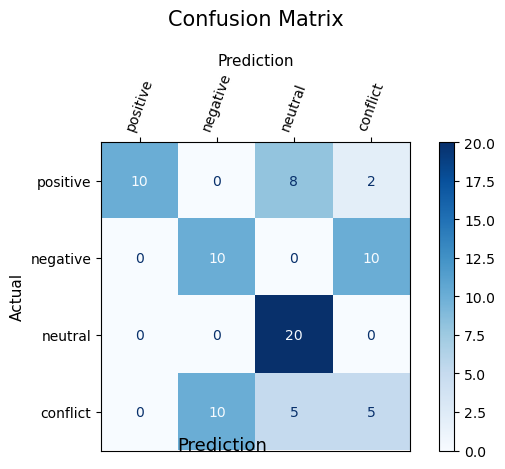

In [361]:
# Generate the confusion matrix

cm = confusion_matrix(ground_truths,model_predictions, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)
#Customizations
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


In [362]:
print(classification_report(ground_truths,model_predictions, labels=np.unique(ground_truths)))

              precision    recall  f1-score   support

    conflict       0.29      0.25      0.27        20
    negative       0.50      0.50      0.50        20
     neutral       0.61      1.00      0.75        20
    positive       1.00      0.50      0.67        20

    accuracy                           0.56        80
   macro avg       0.60      0.56      0.55        80
weighted avg       0.60      0.56      0.55        80



In [363]:
len(ground_truths)

80

In [364]:
len(model_predictions)

80